Normalización de texto y unión del .csv con el .json

In [1]:
import pandas as pd
import json
import unicodedata

def normalize_text(text):
    if not isinstance(text, str): return text
    text = unicodedata.normalize('NFD', text)
    text = "".join([c for c in text if unicodedata.category(c) != 'Mn'])
    return text.lower().strip()

# 1. Carga de datos
df_acc = pd.read_csv('2 Base de accidentes con victimas 2018_ 2024_UTF8.csv', sep=';')
with open('cr.json', 'r', encoding='utf-8') as f:
    df_geo = pd.DataFrame(json.load(f))

df_acc.columns = df_acc.columns.str.strip()

# 2. DICCIONARIO DE CORRECCIÓN
# Mapeamos el nombre del Cantón (CSV) al nombre de la Ciudad (JSON)
mapping_dict = {
    "vazquez de coronado": "san isidro",
    "perez zeledon": "san isidro",
    "san carlos": "quesada",
    "pococi": "guapiles",
    "goicoechea": "guadalupe",
    "montes de oca": "san pedro",
    "moravia": "san vicente",
    "tibas": "san juan",
    "la union": "tres rios",
    "limon": "puerto limon",
    "punterenas": "puntarenas",
    "leon cortes": "san marcos", # San Marcos de Tarrazú/León Cortés comparten zona
    "tarrazu": "san marcos",
    "valverde vega": "sarchi",
    "aguirre": "quepos"
}

# 3. Aplicar normalización y corrección
df_acc['cant_norm'] = df_acc['Cantón'].apply(normalize_text)
# Aplicamos el diccionario: si el cantón está en el mapa, usamos el nombre del JSON
df_acc['cant_norm'] = df_acc['cant_norm'].replace(mapping_dict)

df_geo['cant_norm'] = df_geo['city'].apply(normalize_text)

# 4. Unión mejorada
df_final = pd.merge(
    df_acc,
    df_geo[['lat', 'lng', 'population', 'cant_norm', 'admin_name']],
    left_on=['cant_norm', 'Provincia'],
    right_on=['cant_norm', 'admin_name'],
    how='left'
)

# Limpieza final
df_final = df_final.drop(columns=['cant_norm', 'admin_name'])

print(f"Total registros: {len(df_final)}")
print(f"Registros con coordenadas: {df_final['lat'].notna().sum()}")

# 5. Exportar a CSV
# Se recomienda usar utf-8-sig para que Excel reconozca bien las tildes al abrirlo
df_final.to_csv('accidentes_cr_unido.csv', index=False, encoding='utf-8-sig', sep=';')

print("El archivo 'accidentes_cr_unido.csv' ha sido generado exitosamente.")

Total registros: 109966
Registros con coordenadas: 96747
El archivo 'accidentes_cr_unido.csv' ha sido generado exitosamente.


Limpieza de filas y clumnas con el nuevo csv ya unido

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset unido
df = pd.read_csv('accidentes_cr_unido.csv', sep=';')

# --- LIMPIEZA ---

# 1. Eliminar filas con NaN en coordenadas o población (Limpieza estricta)
df_clean = df.dropna(subset=['lat', 'lng', 'population']).copy()

# 2. Limpiar prefijos en columnas temporales (ej: "1.Domingo" -> "Domingo")
df_clean['Día'] = df_clean['Día'].str.split('.').str[1]
df_clean['Mes'] = df_clean['Mes'].str.split('.').str[1]

# 3. Convertir 'Hora' a un valor numérico (Extraer la hora inicial del rango)
# Ejemplo: "20:00-20:59" -> 20
df_clean['Hora_Inicio'] = df_clean['Hora'].str.split(':').str[0].astype(int)

print(f"Registros después de eliminar NaNs: {len(df_clean)}")

Registros después de eliminar NaNs: 96747


En este caso eliminamos los nulos ya que el .json no tiene todos los 84 cantones


Análisis exploratorio

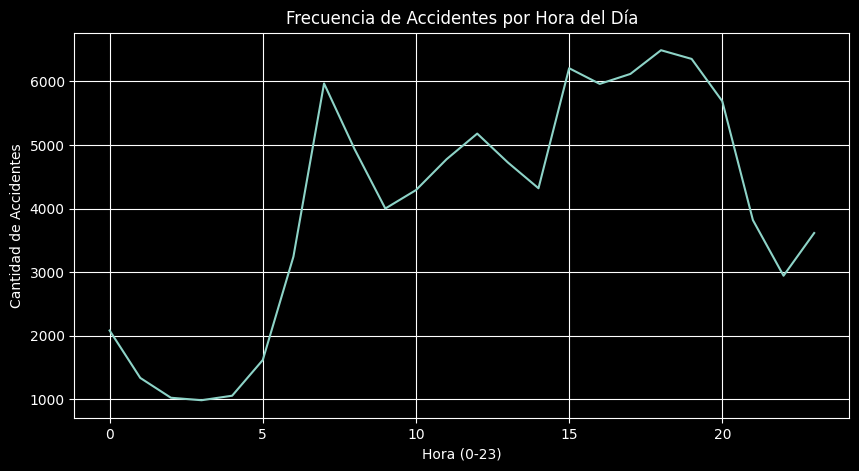

In [4]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_clean['Hora_Inicio'].value_counts().sort_index())
plt.title('Frecuencia de Accidentes por Hora del Día')
plt.xlabel('Hora (0-23)')
plt.ylabel('Cantidad de Accidentes')
plt.grid(True)
plt.show()

In [5]:
print(df_clean)

          Clase de accidente         Tipo de accidente   Año         Hora  \
0         Solo heridos leves           Salió de la vía  2024  20:00-20:59   
1         Solo heridos leves  Colisión con motocicleta  2024  06:00-06:59   
2       Con muertos o graves                    Vuelco  2024  15:00-15:59   
3       Con muertos o graves                    Vuelco  2024  15:00-15:59   
4         Solo heridos leves  Colisión entre vehículos  2024  08:00-08:59   
...                      ...                       ...   ...          ...   
109961    Solo heridos leves  Colisión con motocicleta  2018  15:00-15:59   
109962    Solo heridos leves  Colisión entre vehículos  2018  20:00-20:59   
109963    Solo heridos leves    Colisión con bicicleta  2018  06:00-06:59   
109964  Con muertos o graves  Colisión con motocicleta  2018  17:00-17:59   
109965  Con muertos o graves           Salió de la vía  2018  11:00-11:59   

       Hora recodificada Provincia               Cantón  \
0            18:

In [6]:
df_clean.to_csv('accidentes_cr_final.csv', index=False, encoding='utf-8-sig', sep=';')

print("El archivo 'accidentes_cr_final.csv' ha sido generado exitosamente.")

El archivo 'accidentes_cr_final.csv' ha sido generado exitosamente.


Prueba del mapa con folium

In [8]:
import folium
import pandas as pd
import geopandas as gpd
from folium.plugins import HeatMap, MiniMap

In [9]:
# 1. Carga de datos procesados
# Usamos el separador ';' que definimos en el paso anterior
df = pd.read_csv('accidentes_cr_final.csv', sep=';')

# OPCIONAL: Para que el mapa cargue fluido, puedes tomar una muestra aleatoria
# Si quieres ver TODOS, comenta la siguiente línea:
df_mapa = df.sample(1000) if len(df) > 1000 else df

# 2. Configuración base del mapa
tiles = 'https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}'
atributos = 'Google Satellite'
m = folium.Map(location=(9.748917, -83.753428), zoom_start=8, tiles=tiles, attr=atributos)

# 3. Grupos de Capas (Feature Groups)
# Provincia_Layer = folium.FeatureGroup(name='Capa Provincias').add_to(m) # Requiere el SHP
Heatmap_Group = folium.FeatureGroup(name='Mapa de Calor').add_to(m)

# Crear un grupo por provincia para poder encender/apagar cada una
capas_provincias = {}
for p in df['Provincia'].unique():
    capas_provincias[p] = folium.FeatureGroup(name=f"Accidentes en {p}", show=False).add_to(m)

# 4. Procesamiento de marcadores y datos para el HeatMap
coor_heat = []

for _, fila in df_mapa.iterrows():
    y = fila['lat']
    x = fila['lng']
    prov = fila['Provincia']
    tipo = fila['Tipo de accidente']
    clase = fila['Clase de accidente']

    # Crear el HTML para el Popup
    html = f'''
    <div style="font-family: Arial; font-size: 12px;">
        <h4 style="margin-bottom:5px;">{tipo}</h4>
        <b>Gravedad:</b> {clase}<br>
        <b>Cantón:</b> {fila['Cantón']}<br>
        <b>Población:</b> {int(fila['population'])}<br>
        <b>Lat:</b> {round(y, 4)} | <b>Lng:</b> {round(x, 4)}
    </div>
    '''

    # Definir color de icono según gravedad para tu análisis de ANN
    color = 'red' if 'muertos' in clase.lower() else 'orange'

    # Agregar marcador a la capa de su respectiva provincia
    folium.Marker(
        location=(y, x),
        tooltip=f"{tipo} - {prov}",
        popup=folium.Popup(html, max_width=250),
        icon=folium.Icon(color=color, icon='info-sign')
    ).add_to(capas_provincias[prov])

    # Guardar coordenadas para el mapa de calor (usamos todo el df para el calor si deseas)
    coor_heat.append([y, x])

# 5. Agregar Mapa de Calor (HeatMap)
HeatMap(coor_heat, radius=15).add_to(Heatmap_Group)

# 6. Mini Mapa y Control de Capas
MiniMap(width=150, height=150).add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# Guardar y mostrar
m.save('mapa_accidentes_cr.html')
m